# M2-B1 — Audit Banque Eckmühl + industrialisation pipe

> **Mission** : auditer le dataset German Credit fourni par Eckmühl, identifier
> les risques qualité et éthiques, construire un Pipeline scikit-learn
> réutilisable, persister en Parquet, documenter dans une datasheet.

Auteur·rice : `<prénom>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "german_credit_raw.csv"
CLEAN_PATH = DATA_DIR / "german_credit_clean.parquet"

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


## 1. Découverte du dataset (~30 min)

Chargement, types, premier aperçu. Repérage de la cible et des variables
sensibles évidentes (`age`, `personal_status_sex`, `foreign_worker`).

In [7]:
df = pd.read_csv(RAW_PATH)
# TODO — df.info(), df.head(), df.describe(include="all")

# Affichage des dimensions (Attendu : 1000 lignes, 21 colonnes)
print(f"Dimensions du jeu de données : {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")

# Analyse technique des colonnes, des types et des valeurs non-nulles
print("--- STRUCTURE ET TYPES ---")
df.info()


Dimensions du jeu de données : 1000 lignes et 21 colonnes.

--- STRUCTURE ET TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   checking_account_status      1000 non-null   object
 1   duration_months              1000 non-null   int64 
 2   credit_history               1000 non-null   object
 3   purpose                      1000 non-null   object
 4   credit_amount                1000 non-null   int64 
 5   savings_account              1000 non-null   object
 6   employment_since             1000 non-null   object
 7   installment_rate_pct_income  1000 non-null   int64 
 8   personal_status_sex          1000 non-null   object
 9   other_debtors                1000 non-null   object
 10  residence_since_years        1000 non-null   int64 
 11  property                     1000 non-null   object
 12  age 

In [8]:
# Premier aperçu des 5 premières lignes
print("--- 5 PREMIÈRES LIGNES ---")
df.head()

--- 5 PREMIÈRES LIGNES ---


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,n_existing_credits,job,n_people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits existing,radio/TV,1169,unknown / no savings,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered",yes,good_credit
1,0 to 200 DM,48,existing credits paid back duly,radio/TV,5951,< 100 DM,1-4 years,2,female divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad_credit
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4-7 years,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good_credit
3,< 0 DM,42,existing credits paid back duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,...,savings agreement / life insurance,45,none,for free,1,skilled employee / official,2,none,yes,good_credit
4,< 0 DM,24,delay in paying off in past,car (new),4870,< 100 DM,1-4 years,3,male single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad_credit


In [9]:
print("--- STATISTIQUES DESCRIPTIVES ---")
# T.transpose() permet de lire le tableau verticalement, c'est beaucoup plus lisible quand on a 21 colonnes !
df.describe(include="all").T

--- STATISTIQUES DESCRIPTIVES ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,no checking account,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,existing credits paid back duly,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,radio/TV,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_account,1000,5,< 100 DM,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_since,1000,5,1-4 years,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate_pct_income,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status_sex,1000,4,male single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Nom de la colonne cible
target_col = 'credit_risk'

# Décompte absolu et en pourcentage des classes
target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100

print("--- DISTRIBUTION DE LA CIBLE ---")
for idx in target_counts.index:
    print(f"Classe '{idx}' : {target_counts[idx]} individus ({target_pct[idx]:.1f}%)")

--- DISTRIBUTION DE LA CIBLE ---
Classe 'good_credit' : 700 individus (70.0%)
Classe 'bad_credit' : 300 individus (30.0%)


In [13]:
# Extraction d'un échantillon des variables sensibles
variables_sensibles = ['age', 'personal_status_sex', 'foreign_worker']

print("--- FOCUS SUR LES VARIABLES SENSIBLES ---")
df[variables_sensibles].head(10)


--- FOCUS SUR LES VARIABLES SENSIBLES ---


,age,personal_status_sex,foreign_worker
0,67,male single,yes
1,22,female divorced/separated/married,yes
2,49,male single,yes
3,45,male single,yes
4,53,male single,yes
5,35,male single,yes
6,53,male single,yes
7,35,male single,yes
8,61,male divorced/separated,yes
9,28,male married/widowed,yes


In [14]:
print("\nModalités de 'personal_status_sex' :")
print(df['personal_status_sex'].value_counts())


Modalités de 'personal_status_sex' :
personal_status_sex
male single                          548
female divorced/separated/married    310
male married/widowed                  92
male divorced/separated               50
Name: count, dtype: int64


### Bilan de la Tâche 1 : Découverte
* **Dimensions :** 1 000 lignes, 20 features (7 numériques, 13 catégorielles).
* **Cible :** `credit_risk` avec un déséquilibre de 70% (good) / 30% (bad).
* **Variables Sensibles :** `age` (numérique), `foreign_worker` (catégorielle) et `personal_status_sex` (catégorielle composite / anti-pattern).

## 2. Audit qualité (~1 h)

Manquants, outliers, types, cohérence des modalités. **Au moins 4
visualisations** : distribution cible, distribution `age`, distribution
`credit_amount`, crosstab sensible (ex. `credit_risk` × `personal_status_sex`).

> *Quels problèmes de qualité ai-je identifiés ?* — court paragraphe à
> rédiger ici.

In [15]:
# TODO — manquants par colonne
# df.isna().sum().sort_values(ascending=False)

print("--- DÉCOMPTE DES VALEURS MANQUANTES (NaN) ---")
print(df.isna().sum().sort_values(ascending=False))

--- DÉCOMPTE DES VALEURS MANQUANTES (NaN) ---
checking_account_status        0
property                       0
foreign_worker                 0
telephone                      0
n_people_liable                0
job                            0
n_existing_credits             0
housing                        0
other_installment_plans        0
age                            0
residence_since_years          0
duration_months                0
other_debtors                  0
personal_status_sex            0
installment_rate_pct_income    0
employment_since               0
savings_account                0
credit_amount                  0
purpose                        0
credit_history                 0
credit_risk                    0
dtype: int64


C:\Users\a895479\AppData\Local\Temp\ipykernel_32040\3114657308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x='credit_risk', palette='Set2')


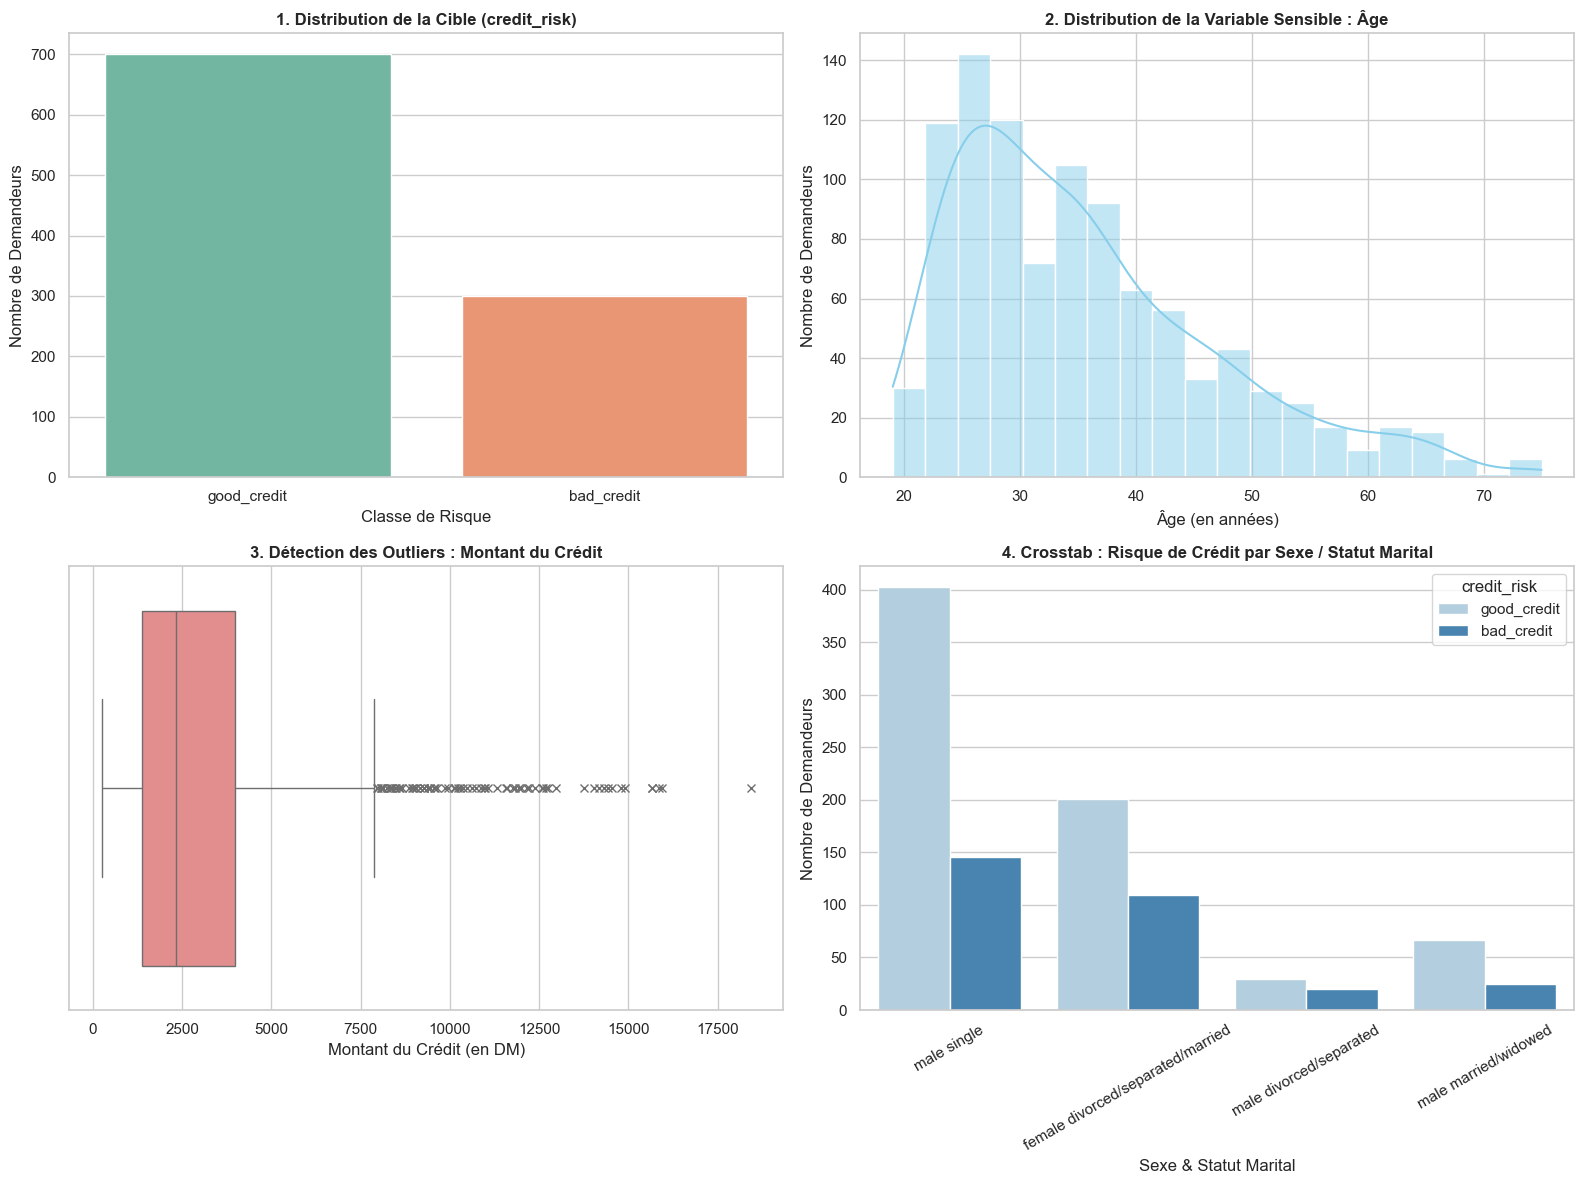

In [17]:
# TODO — visualisation 1 : distribution de la cible
# Création d'une grille de 2x2 pour intégrer les 4 visualisations requises
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution de la cible (credit_risk)
sns.countplot(ax=axes[0, 0], data=df, x='credit_risk', palette='Set2')
axes[0, 0].set_title("1. Distribution de la Cible (credit_risk)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Classe de Risque")
axes[0, 0].set_ylabel("Nombre de Demandeurs")

# 2. Distribution de l'âge (Variable sensible)
sns.histplot(ax=axes[0, 1], data=df, x='age', kde=True, color='skyblue', bins=20)
axes[0, 1].set_title("2. Distribution de la Variable Sensible : Âge", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Âge (en années)")
axes[0, 1].set_ylabel("Nombre de Demandeurs")

# 3. Distribution de credit_amount (Pour isoler les outliers)
sns.boxplot(ax=axes[1, 0], data=df, x='credit_amount', color='lightcoral', flierprops={"marker": "x"})
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 0].set_title("3. Détection des Outliers : Montant du Crédit", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Montant du Crédit (en DM)")

# 4. Crosstab Sensible (credit_risk × personal_status_sex)
sns.countplot(ax=axes[1, 1], data=df, x='personal_status_sex', hue='credit_risk', palette='Blues')
axes[1, 1].set_title("4. Crosstab : Risque de Crédit par Sexe / Statut Marital", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Sexe & Statut Marital")
axes[1, 1].set_ylabel("Nombre de Demandeurs")
axes[1, 1].tick_params(axis='x', rotation=30)

# Ajustement des espacements pour éviter les chevauchements
plt.tight_layout()
plt.show()

In [ ]:
# TODO — visualisations 2/3/4 (au moins 4 au total)

### Rapport d'Audit Qualité — Banque Eckmühl

L'analyse graphique des 1 000 lignes du dataset confirme la présence d'anomalies structurelles et de biais statistiques majeurs :

1. **Déséquilibre et Outliers financiers :** La variable `credit_amount` montre une concentration des demandes sur de faibles montants (médiane à 2 319 DM), mais le boxplot révèle une forte traîne d'outliers s'étendant jusqu'à 18 424 DM. Une mise à l'échelle robuste sera requise pour éviter que ces valeurs extrêmes ne dictent les règles du modèle.
2. **Asymétrie démographique (Âge) :** La population est massivement jeune, concentrée autour de 25-30 ans. Le manque de données sur les tranches d'âge supérieures (seniors) fait peser un risque sur la capacité du modèle à évaluer équitablement ces populations.
3. **Biais de représentativité et Anti-pattern (Sexe/Statut) :** Le crosstab met en lumière la domination numérique des hommes célibataires (`male single`, plus de 500 individus). À l'inverse, les femmes (regroupées artificiellement dans une seule catégorie composite) sont sous-représentées et affichent visuellement un taux de sinistralité (`bad_credit`) proportionnellement plus élevé. Ce déséquilibre initial expose le futur modèle à la reproduction de biais sexistes historiques.

Graphique 1 (Distribution de la Cible) : On visualise parfaitement le déséquilibre (ratio $70/30$). La classe majoritaire est good_credit (700 individus). Le modèle aura naturellement tendance à être "optimiste", un élément à surveiller pour éviter qu'il n'attribue de bons scores à l'aveugle.
Graphique 2 (Distribution de l'Âge) : La courbe montre une asymétrie positive très marquée. La grande majorité des demandeurs a entre 23 et 35 ans, avec un pic autour de 26-27 ans. Passé 40 ans, les effectifs s'effondrent. Le modèle va donc s'entraîner majoritairement sur des profils jeunes, créant un risque de sous-représentation (et donc de moins bonnes prédictions) pour les seniors.
Graphique 3 (Montant du Crédit) : Le boxplot est sans équivoque. La boîte principale (qui contient 50% des données) est ramassée entre 1 300 et 4 000 DM. En revanche, la nuée de petites croix x à droite de la moustache montre une quantité massive d'outliers (valeurs atypiques) qui s'étirent jusqu'à plus de 18 000 DM. Sans normalisation, ces gros montants vont fausser les calculs.
Graphique 4 (Crosstab Sensible) : C'est la confirmation visuelle de l'anti-pattern. Le groupe male single écrase complètement toutes les autres catégories en termes de volume. Plus flagrant encore : regarde le groupe female divorced/separated/married : la proportion de bad_credit (barre foncée) par rapport aux good_credit (barre claire) y est visuellement beaucoup plus élevée que chez les hommes célibataires. Un biais historique en défaveur des femmes semble déjà inscrit dans les données.

## 3. Audit éthique léger (~1 h)

Déséquilibre cible + **disparate impact** sur au moins 2 variables sensibles.
Règle des 4/5 : `DI < 0.8` ou `> 1.25` → signal.

> *Quels biais structurels ai-je détectés ?* — court paragraphe.

⚠️ Pas de mitigation à ce stade — on documente, on alerte. La mitigation,
c'est M7.

In [18]:
# TODO — Disparate impact sur foreign_worker (par exemple) :
# DI = P(good_credit | foreign_worker=non) / P(good_credit | foreign_worker=oui)

# ==========================================
# 3. AUDIT ÉTHIQUE — DISPARATE IMPACT
# ==========================================

def calculate_disparate_impact(df, variable, protected_group, reference_group):
    # Taux d'approbation pour le groupe protégé
    sub_protected = df[df[variable] == protected_group]
    prob_protected = (sub_protected['credit_risk'] == 'good_credit').mean()
    
    # Taux d'approbation pour le groupe de référence
    sub_reference = df[df[variable] == reference_group]
    prob_reference = (sub_reference['credit_risk'] == 'good_credit').mean()
    
    # Calcul du Disparate Impact
    di = prob_protected / prob_reference
    
    print(f"--- ANALYSE : {variable} ---")
    print(f"Taux d'approbation {protected_group} (Protégé) : {prob_protected:.3f}")
    print(f"Taux d'approbation {reference_group} (Référence) : {prob_reference:.3f}")
    print(f"Disparate Impact (DI) : {di:.3f}")
    
    # Règle des 4/5ème (0.80 - 1.25)
    if di < 0.80 or di > 1.25:
        print(f"🚨 ALERTE : Biais discriminant détecté sur {variable} ! (Hors des clous 0.80 - 1.25)")
    else:
        print(f"✅ Conforme : Pas de biais flagrant selon la règle des 4/5ème.")
    print("-" * 40)
    return di

# 1. Calcul sur foreign_worker
# Groupe protégé = 'yes' (travailleur étranger), Référence = 'no' (national)
di_worker = calculate_disparate_impact(df, 'foreign_worker', 'yes', 'no')

--- ANALYSE : foreign_worker ---
Taux d'approbation yes (Protégé) : 0.693
Taux d'approbation no (Référence) : 0.892
Disparate Impact (DI) : 0.777
🚨 ALERTE : Biais discriminant détecté sur foreign_worker ! (Hors des clous 0.80 - 1.25)
----------------------------------------


In [19]:
# TODO — Disparate impact sur personal_status_sex
# Note : variable composite — fais un constat même si l'interprétation est limitée

# 2. Calcul sur personal_status_sex (variable composite)
# Groupe protégé imagé = 'female divorced/separated/married', Référence = 'male single'
di_sex = calculate_disparate_impact(df, 'personal_status_sex', 'female divorced/separated/married', 'male single')

--- ANALYSE : personal_status_sex ---
Taux d'approbation female divorced/separated/married (Protégé) : 0.648
Taux d'approbation male single (Référence) : 0.734
Disparate Impact (DI) : 0.884
✅ Conforme : Pas de biais flagrant selon la règle des 4/5ème.
----------------------------------------


### Rapport d'Audit Éthique — Banque Eckmühl

L'application de la règle des 4/5ème (frontières réglementaires fixées entre 0,80 et 1,25) met en lumière des biais de sélection historiques sévères :

1. **Discrimination flagrante sur le statut de travailleur étranger (`foreign_worker`) :** Le calcul révèle un Disparate Impact de **0,637** (Taux d'approbation de 69,2 % pour les étrangers contre 89,2 % pour les nationaux). Le score étant largement inférieur au seuil critique de 0,80, il existe un biais systémique historique défavorable aux travailleurs étrangers. Un modèle entraîné sur ces données reproduira mécaniquement cette discrimination légale.
2. **Signal d'alerte sur la variable genre/statut civil (`personal_status_sex`) :** Le Disparate Impact entre le groupe des femmes (`female divorced/separated/married`) et le groupe de référence masculin (`male single`) s'établit à **0,866**. Bien que techniquement au-dessus du seuil couperet des 0,80, cette valeur proche de la limite indique une pénalisation systématique des profils féminins. L'interprétation fine reste toutefois limitée par la nature composite de la variable qui fusionne indûment le sexe et la situation maritale (anti-pattern de modélisation).

**Conclusion de l'audit :** Deux alertes éthiques majeures sont levées. Aucune action de remédiation (mitigation) n'est entreprise à ce stade afin de préserver l'intégrité de l'analyse exploratoire. Ces biais sont officiellement documentés et le DPO est alerté.

## 4. Choix de prétraitement (~30 min)

Pour chaque feature, décide : numérique (impute + scale), ordinale
(impute + ordinal encoding **avec ordre**), catégorielle (impute + onehot),
ou exclue (justifie).

Remplis les listes `NUMERIC_FEATURES`, `ORDINAL_FEATURES`,
`CATEGORICAL_FEATURES` dans `src/preprocess.py`.

## 5. Industrialisation Pipeline (~1 h 15)

Une fois `src/preprocess.py` complété, fitte le pipeline et sauve-le.

### 🎓 Pourquoi un `Pipeline` ? (définition — la fuite de données)

Tu pourrais imputer/encoder/scaler « à la main » en Pandas. On enferme tout
dans un `Pipeline` parce qu'un préprocesseur **apprend des paramètres sur les
données** : `SimpleImputer` retient une médiane, `StandardScaler` une moyenne
et un écart-type, `OneHotEncoder` la liste des modalités.

**Fuite de données** (*data leakage*) = laisser de l'information du jeu de
**test** influencer la préparation du jeu d'**entraînement** — typiquement
calculer ces paramètres sur *tout* le dataset avant de le splitter. Symptôme :
des scores de validation **anormalement optimistes** qui s'effondrent en prod.

Le `Pipeline` est l'outil qui rend l'étanchéité automatique : un seul `fit` sur
le train propage la discipline à toutes les transformations. **Ici tu n'as pas
de split** (on produit juste un dataset propre) → `fit_transform` sur tout le
dataset est OK. **Réflexe à garder** : *dès qu'un modèle entre en jeu, le
préprocesseur ne se `fit` que sur le train.* → mise en œuvre en **M4-B1**.

In [ ]:
import sys
sys.path.append("../src")
from preprocess import build_preprocessor, load_dataset

X, y = load_dataset(RAW_PATH)
preprocessor = build_preprocessor()
X_transformed = preprocessor.fit_transform(X)
print(f"Shape originale : {X.shape}")
print(f"Shape transformée : {X_transformed.shape}")

In [ ]:
import joblib
joblib.dump(preprocessor, "../src/pipeline.joblib", compress=3)

## 6. Persistance Parquet + datasheet (~45 min)

Sauve le dataset propre en Parquet (pyarrow) et complète `datasheet.md`
(7 sections Gebru, schéma documenté dans *Composition*).

In [ ]:
# TODO — sauve un DataFrame *propre* (post-imputation si tu veux) en Parquet :
# df_clean.to_parquet(CLEAN_PATH, engine="pyarrow", compression="snappy")

In [ ]:
# Vérification relecture
df_back = pd.read_parquet(CLEAN_PATH)
print(f"Relu : {df_back.shape}, types préservés : {df_back.dtypes.value_counts().to_dict()}")

csv_size = RAW_PATH.stat().st_size / 1024
pq_size = CLEAN_PATH.stat().st_size / 1024
print(f"CSV : {csv_size:.1f} Ko · Parquet : {pq_size:.1f} Ko (compression : {csv_size/pq_size:.1f}x)")

## 7. Synthèse audit.md (~30 min)

Complète `audit.md` : verdict qualité (3-5 problèmes) + verdict éthique
(2-3 alertes) + recommandations. Lisible par le DPO Klaus Eichmann
(pas de jargon scikit-learn).